In [1]:
import os
import pickle
import numpy as np
import emcee
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import Flatw0waCDM
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference

# --- CONFIGURATION ---
DATA_PATH = '../data/samples/pdspl_samples_with_pairs.pkl'
POSTERIOR_DIR = './posteriors_split_selection_fixed_scatter'
os.makedirs(POSTERIOR_DIR, exist_ok=True)

# Define "True" Universe
truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}

# Fixed params for MCMC (we fix H0 and the scatter coefficients)
# beta_c0 and beta_c1 will be fixed using the polynomial fits
# We fix H0 and the higher-order scatter term (c2) if not used
fixed_params = {'h0': 70.0, 'beta_c2': 0.0}

cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

In [2]:
with open(DATA_PATH, 'rb') as f:
    pdspl_samples = pickle.load(f)

# Extract tables and coefficients
pairs_table = pdspl_samples['lsst_y10']['pairs_analysis']['pairs_table']
pairs_table_err = pdspl_samples['lsst_y10']['pairs_analysis']['pairs_table_with_errors']
fit_coeffs = pdspl_samples['lsst_y10']['pairs_analysis']['scatter_vs_dissimilarity_fit_coeffs']

# Mapping coefficients: [c1, c0] for linear or [c2, c1, c0] for quadratic
# In inference script: sigma = c0 + c1*D + c2*D^2
fixed_params['beta_c1'] = fit_coeffs[-2] # Slope (c1)
fixed_params['beta_c0'] = fit_coeffs[-1] # Intercept (c0)

dissimilarity_cuts = np.linspace(0.01, 0.08, 8)
scenarios = {}

for cut in dissimilarity_cuts:
    mask = pairs_table_err['dissimilarity'] <= cut
    num_pairs = np.sum(mask)
    if num_pairs < 10: continue # Skip tiny samples

    # Normalize weight to 500 lenses
    down_sampling = num_pairs / 500 if num_pairs > 500 else 1.0
    
    key = f'lsst_y10_dissim_leq_{cut:.3f}'
    scenarios[key] = {
        'name': f"D <= {cut:.3f}",
        'down_sampling': down_sampling,
        'indices': np.where(mask)[0],
        'backend_path': os.path.join(POSTERIOR_DIR, f"{key}.h5")
    }

print(f"Fixed Scatter Model: sigma = {fixed_params['beta_c0']:.4f} + {fixed_params['beta_c1']:.4f} * D")

Fixed Scatter Model: sigma = 0.1496 + 0.8931 * D


In [3]:
print(f"{'SCENARIO':<30} | {'N_LENS':<10} | {'STATUS'}")
for key, sc in scenarios.items():
    num_samples = int(len(sc['indices']) / sc['down_sampling'])
    kwargs_list = []
    
    # Sub-sample indices for this cut
    selected_idx = np.random.choice(sc['indices'], size=num_samples, replace=False)
    
    for i in selected_idx:
        z_l = pairs_table["z_D"][i]
        z1 = pairs_table["z_S1"][i]
        z2 = pairs_table["z_S2"][i]
        dissim = pairs_table_err['dissimilarity'][i]
        
        # Use the specific fit to set the 'intrinsic' scatter for this lens
        rel_scatter = np.polyval(fit_coeffs, dissim)
        
        kwargs_list.append(draw_lens_from_given_zs(
            z_lens=z_l, z1=z1, z2=z2,
            lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
            gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
            sigma_meas_rel=0.0141, # sqrt(0.01^2 + 0.01^2) from meas. + los
            sigma_beta_intrinsic=rel_scatter, 
            dissimilarity=dissim,
            down_sampling=sc['down_sampling'],
            with_noise=False, 
            cosmo=cosmo_true,
            redshift_error_rel=0.03
        ))
    
    sc['kwargs_list'] = kwargs_list
    print(f"{sc['name']:<30} | {num_samples:<10} | GENERATED")

SCENARIO                       | N_LENS     | STATUS
D <= 0.010                     | 500        | GENERATED
D <= 0.020                     | 499        | GENERATED
D <= 0.030                     | 500        | GENERATED
D <= 0.040                     | 500        | GENERATED
D <= 0.050                     | 500        | GENERATED
D <= 0.060                     | 500        | GENERATED
D <= 0.070                     | 500        | GENERATED
D <= 0.080                     | 499        | GENERATED


In [4]:
my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}
my_spreads = {k: 0.02 for k in my_guess.keys()}

my_spreads.update({
    'w0': 0.05, 
    'wa': 0.2
})

for key, sc in scenarios.items():
    # if os.path.exists(sc['backend_path']):
    #     print(f"Found existing backend for {key}. Skipping.")
    #     continue
        
    print(f"Running MCMC: {sc['name']}")
    run_dspl_inference(
        sc['kwargs_list'],
        n_walkers=64,
        n_steps=3000,
        n_burn=200,
        initial_guess=my_guess,
        initial_scatter=my_spreads,
        fixed_params=fixed_params,
        backend_path=sc['backend_path']
    )

Running MCMC: D <= 0.010
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c2', 'beta_c1', 'beta_c0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 3000/3000 [12:38<00:00,  3.96it/s]


Running MCMC: D <= 0.020
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c2', 'beta_c1', 'beta_c0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 3000/3000 [13:18<00:00,  3.76it/s]


Running MCMC: D <= 0.030
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c2', 'beta_c1', 'beta_c0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


...

100%|██████████| 3000/3000 [14:12<00:00,  3.52it/s]


Running MCMC: D <= 0.070
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c2', 'beta_c1', 'beta_c0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 3000/3000 [14:08<00:00,  3.53it/s]


Running MCMC: D <= 0.080
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c2', 'beta_c1', 'beta_c0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 3000/3000 [14:11<00:00,  3.52it/s]


In [5]:
print(f"{'SCENARIO':<30} | {'MEAN TAU':<10} | {'CONVERGED?'}")
print("-" * 55)

burnin_dict = {}

for key, sc in scenarios.items():
    try:
        reader = emcee.backends.HDFBackend(sc['backend_path'], read_only=True)
        # We check the last 70% of the chain for tau estimation
        tau = reader.get_autocorr_time(tol=0) 
        mean_tau = np.mean(tau)
        
        # Convergence Rule: Chain Length > 50 * max(tau)
        is_converged = reader.get_chain().shape[0] > 50 * np.max(tau)
        
        # Set burn-in as 3 times the max autocorrelation time
        burnin_dict[key] = int(3 * np.max(tau))
        
        status = "✅ YES" if is_converged else "❌ NO (Short)"
        print(f"{sc['name']:<30} | {mean_tau:>8.1f} | {status}")
        
    except emcee.autocorr.AutocorrError:
        print(f"{sc['name']:<30} | {'N/A':>8} | ❌ NO (Short)")
        burnin_dict[key] = 200 # Fallback default

SCENARIO                       | MEAN TAU   | CONVERGED?
-------------------------------------------------------
D <= 0.010                     |    133.0 | ❌ NO (Short)
D <= 0.020                     |    155.6 | ❌ NO (Short)
D <= 0.030                     |    157.8 | ❌ NO (Short)
D <= 0.040                     |    139.6 | ❌ NO (Short)
D <= 0.050                     |    142.0 | ❌ NO (Short)
D <= 0.060                     |    141.5 | ❌ NO (Short)
D <= 0.070                     |    145.4 | ❌ NO (Short)
D <= 0.080                     |    143.7 | ❌ NO (Short)


Skipping lsst_y10_dissim_leq_0.070 for precision calculation due to insufficient convergence.
Skipping lsst_y10_dissim_leq_0.080 for precision calculation due to insufficient convergence.


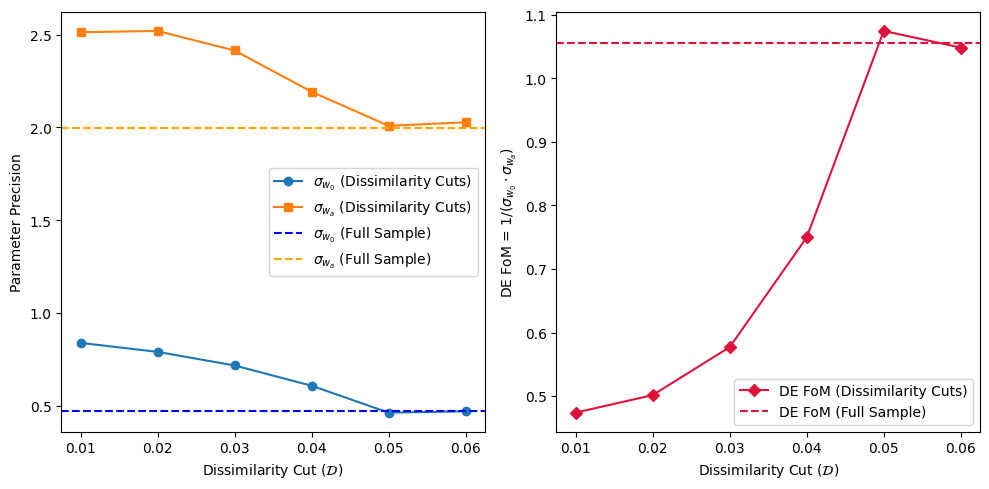

In [17]:
final_results = []

for key, sc in scenarios.items():

    cut = sc['name'].split('<=')[-1].strip()
    cut = float(cut)
    if cut > 0.06:
        print(f"Skipping {key} for precision calculation due to insufficient convergence.")
        continue
    reader = emcee.backends.HDFBackend(sc['backend_path'], read_only=True)
    
    # Use the specific burn-in for this scenario
    b_in = burnin_dict.get(key, 400)
    samples = reader.get_chain(discard=b_in, flat=True)
    
    # 0:Om, 1:w0, 2:wa, 3:lam_int, 4:sig_lam, 5:gam_pl, 6:sig_gam
    sig_w0 = np.std(samples[:, 1])
    sig_wa = np.std(samples[:, 2])
    
    # Calculate Dark Energy Figure of Merit
    # FoM = 1 / sqrt(det(Cov(w0, wa))) is the formal definition,
    # but 1 / (std_w0 * std_wa) is a common proxy for forecasts.
    fom = 1.0 / (sig_w0 * sig_wa)
    
    diss_cut = float(key.split('_')[-1])
    final_results.append((diss_cut, sig_w0, sig_wa, fom))

final_results.sort()
d_vals, w0_precs, wa_precs, foms = zip(*final_results)


# full sample results (no dissimilarity cut)
full_key = 'posteriors_split_selection/lsst_y10_dissim_full_sample.h5'
full_reader = emcee.backends.HDFBackend(full_key, read_only=True)
full_burnin = burnin_dict.get(full_key, 400)
full_samples = full_reader.get_chain(discard=full_burnin, flat=True)
full_sig_w0 = np.std(full_samples[:, 1])
full_sig_wa = np.std(full_samples[:, 2])
full_fom = 1.0 / (full_sig_w0 * full_sig_wa)

# Plotting the precision trend
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(d_vals, w0_precs, 'o-', label=r'$\sigma_{w_0}$ (Dissimilarity Cuts)')
plt.plot(d_vals, wa_precs, 's-', label=r'$\sigma_{w_a}$ (Dissimilarity Cuts)')
plt.axhline(full_sig_w0, color='blue', linestyle='--', label=r'$\sigma_{w_0}$ (Full Sample)')
plt.axhline(full_sig_wa, color='orange', linestyle='--', label=r'$\sigma_{w_a}$ (Full Sample)')
plt.xlabel('Dissimilarity Cut ($\\mathcal{D}$)')
plt.ylabel('Parameter Precision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(d_vals, foms, 'D-', color='crimson', label='DE FoM (Dissimilarity Cuts)')
plt.axhline(full_fom, color='crimson', linestyle='--', label='DE FoM (Full Sample)')
plt.legend()
plt.xlabel('Dissimilarity Cut ($\\mathcal{D}$)')
plt.ylabel('DE FoM = $1 / (\\sigma_{w_0} \\cdot \\sigma_{w_a})$')
plt.tight_layout()
plt.show()